# Urban Demographics for City Management: Population Projection and Service-Demand Planning

**The problem.** A mid-sized city's planning department has a 25-year horizon for major capital decisions — school buildings, hospital extensions, long-term-care facilities, transit lines. Each decision is irreversible, expensive (€10-100M), and has a 30-year useful life. Getting the demographic projection wrong in either direction is expensive: **under-build** and you have waiting lists, overcrowding, and voters who move elsewhere; **over-build** and you sink capital into half-empty facilities that still carry maintenance costs. The question this notebook answers: **given current age-sex populations across a city's districts plus fertility, mortality, and migration assumptions, how do we project district-level service demand for schools, healthcare, and long-term care over 25 years, with uncertainty intervals suitable for capital planning?**

**The approach.** The industry-standard **cohort-component** method (Whelpton 1936; UN DESA 2019), still the reference for UN WPP, Eurostat, and every national statistical office:

1. Simulate a 10-district city (baseline 2025 populations, district-specific demographic profiles: young-family / urban-core / aging-suburb / transitioning).
2. Baseline data diagnostics — population pyramids, dependency ratios, inter-district contrasts.
3. **Cohort-component mechanics**: Leslie-matrix projection with explicit survival, fertility, and migration components at 5-year intervals.
4. **Deterministic 25-year projection** — the central planning scenario.
5. **Stochastic Monte Carlo projection** — propagates uncertainty in fertility, mortality, and migration into district-population trajectories.
6. **Service-demand translation**: school-age (5-18), working-age (18-65), elderly (65-79), very elderly (80+) populations at district × year.
7. **Capacity-gap analysis** against current service capacity assumptions; identify where investment is needed first.
8. **Investment prioritisation** across districts and service types, under explicit uncertainty.
9. **City-level dependency ratios** and fiscal-pressure indicators.

**Audience.** Municipal planning departments, urban-economics analysts, infrastructure investors, policy teams sizing education / health / LTC capital programmes, and senior DS working on any spatial / temporal forecasting problem with policy stakes.


## 0. Setup and reproducibility

All randomness is seeded so the city simulation, projection paths, and investment priorities reproduce identically across runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 130)


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating a multi-district city

A realistic city has districts with very different demographic profiles — and those differences matter for service planning. A 20-year-old "family suburb" built for 1990s-era first-time buyers is, by the mid-2020s, full of empty-nesters approaching care needs. A newly-redeveloped urban core attracts childless professionals. Districts at different points in a demographic life cycle need different services; planning a city by averaging to the mean misses this.

We simulate **10 districts in 5-year age bins × 2 sexes**, with four archetype profiles assigned at random:

- **young_family** (3 districts): age structure skewed toward 0-14 and 30-44, high fertility, net in-migration of young families.
- **urban_core** (3 districts): 25-40 year-olds concentrated, low fertility, high churn (in + out migration).
- **aging_suburb** (3 districts): 55-80 year-olds dominant, low fertility, net out-migration of young people.
- **transitioning** (1 district): mixed and in flux.

Baseline year is **2025**; projection horizon runs to **2050**.


In [2]:
# --- Age and sex structure ---
AGE_BINS = [f"{5*i}-{5*i+4}" for i in range(17)] + ["85+"]   # 18 five-year bins: 0-4, 5-9, ..., 80-84, 85+
AGE_MIDPOINTS = np.array([2.5 + 5 * i for i in range(17)] + [92.5])
SEXES = ["F", "M"]
n_ages = len(AGE_BINS)

# --- Ten districts with archetype assignments ---
DISTRICT_NAMES = [f"D{i+1:02d}" for i in range(10)]
ARCHETYPES = ["young_family", "young_family", "young_family",
              "urban_core", "urban_core", "urban_core",
              "aging_suburb", "aging_suburb", "aging_suburb",
              "transitioning"]

# Age-profile weights per archetype (relative population share by age bin, female side; males roughly symmetric)
def age_profile(archetype: str) -> np.ndarray:
    x = AGE_MIDPOINTS
    if archetype == "young_family":
        # skewed toward 0-14 and 30-44
        weights = np.exp(-((x - 5) / 15) ** 2) * 0.9 + np.exp(-((x - 35) / 10) ** 2) * 1.2 + 0.15
    elif archetype == "urban_core":
        # 25-40 concentrated
        weights = np.exp(-((x - 32) / 8) ** 2) * 1.8 + 0.20
    elif archetype == "aging_suburb":
        # 55-80 dominant
        weights = np.exp(-((x - 65) / 15) ** 2) * 1.5 + 0.12
    else:  # transitioning
        weights = 0.5 * np.exp(-((x - 25) / 15) ** 2) + 0.7 * np.exp(-((x - 55) / 15) ** 2) + 0.15
    return weights / weights.sum()

# Simulate baseline population by district, age, sex
rng = np.random.default_rng(42)
district_totals = rng.integers(low=25_000, high=75_000, size=len(DISTRICT_NAMES))   # per-district residents

# Build the baseline population tensor: shape (n_districts, n_ages, 2) for F, M
baseline_pop = np.zeros((len(DISTRICT_NAMES), n_ages, 2))
for d, (name, arch) in enumerate(zip(DISTRICT_NAMES, ARCHETYPES)):
    profile = age_profile(arch)
    # Slight sex imbalance: more women at older ages (survival differential)
    sex_ratio_M = np.linspace(1.02, 0.65, n_ages)    # M/F ratio by age
    female_share = 1 / (1 + sex_ratio_M)
    pop_by_age = profile * district_totals[d]
    baseline_pop[d, :, 0] = pop_by_age * female_share    # F
    baseline_pop[d, :, 1] = pop_by_age * (1 - female_share) # M

print(f"City: {len(DISTRICT_NAMES)} districts, {int(baseline_pop.sum()):,} total residents in 2025")
print(f"District totals: min={int(baseline_pop.sum(axis=(1,2)).min()):,}, max={int(baseline_pop.sum(axis=(1,2)).max()):,}")
print()
print("District archetypes:")
for name, arch, total in zip(DISTRICT_NAMES, ARCHETYPES, baseline_pop.sum(axis=(1,2))):
    print(f"  {name}  {arch:15s}  total = {int(total):>7,}")


City: 10 districts, 466,355 total residents in 2025
District totals: min=29,296, max=67,929

District archetypes:
  D01  young_family     total =  29,462
  D02  young_family     total =  63,696
  D03  young_family     total =  57,727
  D04  urban_core       total =  46,943
  D05  urban_core       total =  46,650
  D06  urban_core       total =  67,929
  D07  aging_suburb     total =  29,296
  D08  aging_suburb     total =  59,868
  D09  aging_suburb     total =  35,072
  D10  transitioning    total =  29,707


## 2. Baseline diagnostics — population pyramids and dependency ratios

Two canonical demographic diagnostics before any projection:

- **Population pyramids** (age-sex histograms by district): the instantly recognisable summary of a demographic profile.
- **Dependency ratios**: the ratio of non-working-age (children + elderly) to working-age population. Numbers above 0.7 flag districts under fiscal pressure.


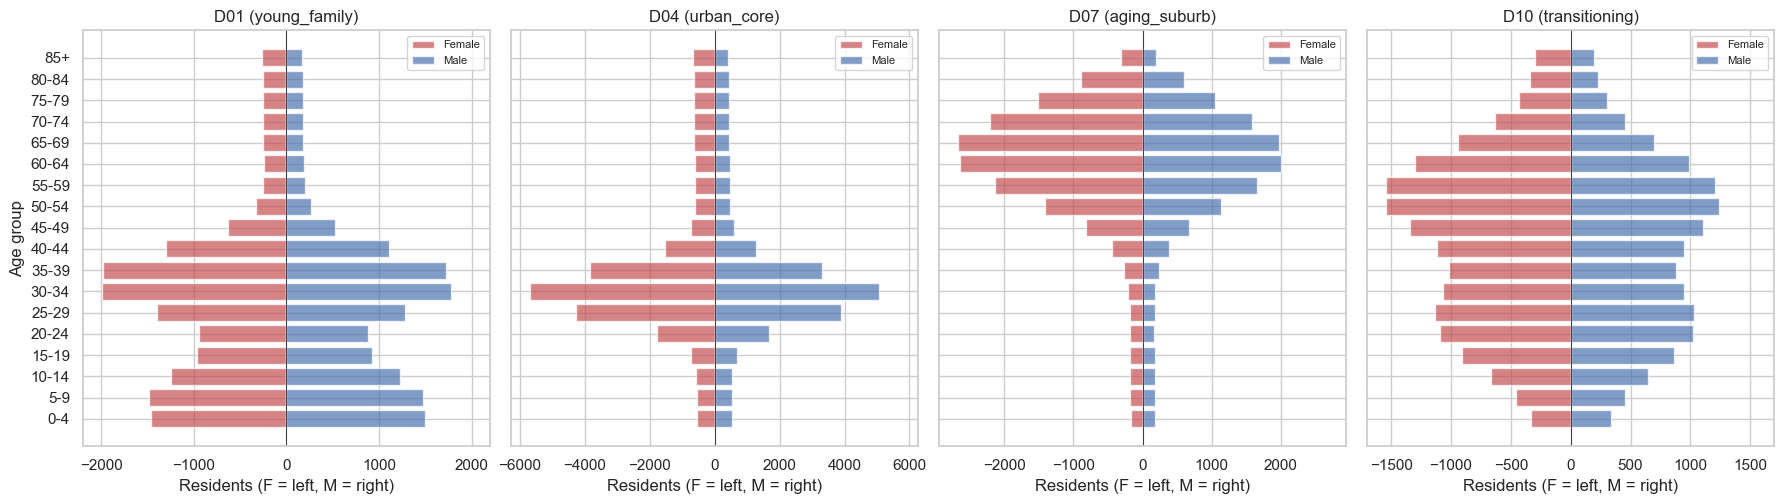

In [3]:
# --- Population pyramid for a representative district of each archetype ---
rep_districts = {
    "young_family": "D01",
    "urban_core":   "D04",
    "aging_suburb": "D07",
    "transitioning":"D10",
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5.2), sharey=True)
for ax, (arch, district) in zip(axes, rep_districts.items()):
    d = DISTRICT_NAMES.index(district)
    pyramid_F = baseline_pop[d, :, 0]
    pyramid_M = baseline_pop[d, :, 1]
    ax.barh(AGE_BINS, -pyramid_F, color="#C44E52", alpha=0.7, label="Female")
    ax.barh(AGE_BINS, pyramid_M, color="#4C72B0", alpha=0.7, label="Male")
    ax.set_title(f"{district} ({arch})")
    ax.set_xlabel("Residents (F = left, M = right)")
    ax.axvline(0, color="black", linewidth=0.5)
    # Symmetric x-axis
    xmax = max(pyramid_F.max(), pyramid_M.max()) * 1.1
    ax.set_xlim(-xmax, xmax)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("Age group")
plt.tight_layout()
plt.show()


In [4]:
# --- Dependency ratios per district ---
# Child dependency: ages 0-14 (bins 0-2)
# Old-age dependency: ages 65+ (bins 13-17)
# Working-age: 15-64 (bins 3-12)

idx_children = list(range(0, 3))    # 0-4, 5-9, 10-14
idx_elderly  = list(range(13, 18))  # 65-69 ... 85+
idx_working  = list(range(3, 13))   # 15-19 ... 60-64

rows = []
for d, name in enumerate(DISTRICT_NAMES):
    pop_d = baseline_pop[d].sum(axis=1)   # sum over sex
    children = pop_d[idx_children].sum()
    elderly  = pop_d[idx_elderly].sum()
    working  = pop_d[idx_working].sum()
    rows.append({
        "district": name,
        "archetype": ARCHETYPES[d],
        "total": int(pop_d.sum()),
        "children_0-14": int(children),
        "working_15-64": int(working),
        "elderly_65+": int(elderly),
        "child_dep_ratio": children / working,
        "old_age_dep_ratio": elderly / working,
        "total_dep_ratio": (children + elderly) / working,
    })
dep_df = pd.DataFrame(rows).round(3)
print("Baseline dependency ratios (2025):")
print(dep_df.to_string(index=False))


Baseline dependency ratios (2025):
district     archetype  total  children_0-14  working_15-64  elderly_65+  child_dep_ratio  old_age_dep_ratio  total_dep_ratio
     D01  young_family  29462           8386          18913         2161            0.443              0.114            0.558
     D02  young_family  63697          18132          40890         4673            0.443              0.114            0.558
     D03  young_family  57728          16433          37059         4235            0.443              0.114            0.558
     D04    urban_core  46943           3262          38288         5392            0.085              0.141            0.226
     D05    urban_core  46650           3241          38049         5359            0.085              0.141            0.226
     D06    urban_core  67929           4720          55404         7803            0.085              0.141            0.226
     D07  aging_suburb  29296           1058          15259        12978           

**What to read here.** The four pyramids are the textbook archetypes: young-family pyramids are wide at the base and mid-adult, urban-core pyramids are narrow with a 25-40 bulge, aging-suburb pyramids are top-heavy and often have a visible narrowing at 30-45 (the missing cohorts who moved elsewhere). The dependency-ratio table quantifies the fiscal implication: total dependency ratios above ~0.7 signal districts where **fewer than 60% of residents are working-age** and the pressure on city services is disproportionate. Aging suburbs typically sit at 0.8-1.0; urban cores at 0.4-0.5.


## 3. Cohort-component projection mechanics

Cohort-component is the standard demographic projection framework (UN DESA 2019; US Census Bureau). At each projection step of length 5 years, the city population updates via three components:

**Survival (age forward)**. Each age-sex bin at time *t* becomes the next-older bin at time *t+5*, shrunk by the 5-year survival probability:

$$P^{t+5}_{x+5} = P^t_x \cdot s(x, \text{sex})$$

**Fertility (births)**. Newborns enter the 0-4 bin. The number is driven by age-specific fertility rates (ASFR) applied to the female population of reproductive age (15-49):

$$\text{births} = \sum_{x \in [15, 49]} \text{ASFR}(x) \cdot F_x \cdot 5$$

**Migration (net inflow/outflow)**. Each district has age-sex-specific net migration rates. Applied as a multiplicative adjustment or additive flows per 5-year bin.

We implement this as an explicit stepwise update (clearer than a single Leslie matrix for a 10-district, 18-age, 2-sex system).


In [5]:
# --- Demographic rates ---
# 5-year survival probabilities (age -> age+5), sex-specific, roughly calibrated to current European life tables
def survival_5yr(sex: str) -> np.ndarray:
    # From each age group, probability of surviving 5 more years
    # 5-year survival probs calibrated to modern European female life tables
    base = np.array([0.996, 0.999, 0.998, 0.997, 0.994, 0.990, 0.987, 0.983, 0.978, 0.970,
                     0.958, 0.942, 0.920, 0.885, 0.820, 0.720, 0.540, 0.250])
    if sex == "M":
        # Males have ~2-8% higher 5-yr mortality at adult ages
        base = base * np.array([1.00, 1.00, 0.998, 0.995, 0.990, 0.985, 0.982, 0.978, 0.972, 0.965,
                                0.955, 0.940, 0.915, 0.880, 0.835, 0.770, 0.650, 0.500])
    return base


SURV_F = survival_5yr("F")
SURV_M = survival_5yr("M")

# Age-specific fertility rates (ASFR) — per female per year
# Reproductive ages bins 3-9 (15-19 to 45-49)
ASFR_BASE = np.zeros(n_ages)
ASFR_BASE[3:10] = [0.008, 0.042, 0.088, 0.105, 0.078, 0.038, 0.009]   # peaks at 30-34

# District-specific fertility multipliers by archetype (tfr = 2*(asfr*5).sum() -> female births)
FERTILITY_MULT = {"young_family": 1.10, "urban_core": 0.80, "aging_suburb": 0.85, "transitioning": 1.00}
SEX_RATIO_AT_BIRTH_F = 0.487   # fraction of births that are female

# Net migration rates per 5 years, sex-averaged, by archetype × age bin
# Positive = net inflow to district, negative = net outflow
def migration_rates(archetype: str) -> np.ndarray:
    # Net 5-year migration rates. Realistic range: 2-10% per 5 years for moderate flows.
    r = np.zeros(n_ages)
    if archetype == "young_family":
        r[3:7] = [0.02, 0.04, 0.06, 0.04]   # young adults & families
        r[0:3] = [0.03, 0.03, 0.02]          # children that come with them
    elif archetype == "urban_core":
        r[4:8] = [0.08, 0.10, 0.05, 0.02]   # in-migration of young professionals
        r[9:13] = [-0.04, -0.06, -0.04, -0.03]  # out-migration to suburbs at family formation
    elif archetype == "aging_suburb":
        r[3:8] = [-0.05, -0.04, -0.03, -0.02, -0.01]   # young adults leave
        r[12:] = [0.01, 0.02, 0.03, 0.02, 0.00, -0.02]  # old age in-migration for LTC
    else:  # transitioning
        r[3:10] = 0.01
    return r


def project_one_step(pop: np.ndarray, archetype: str, fertility_mult: float, surv_shock: float = 1.0, fert_shock: float = 1.0, mig_shock: float = 1.0) -> np.ndarray:
    """Apply survival + fertility + migration for one 5-year step. Returns new (n_ages, 2) population."""
    new_pop = np.zeros_like(pop)

    # --- Survival: each age becomes age+5 ---
    new_pop[1:, 0] = pop[:-1, 0] * SURV_F[:-1] * surv_shock     # F: age 0-4 -> 5-9, ..., 80-84 -> 85+
    new_pop[1:, 1] = pop[:-1, 1] * SURV_M[:-1] * surv_shock     # M
    # 85+ bin includes survivors from 80-84 AND original 85+ survivors (open-ended group)
    new_pop[-1, 0] += pop[-1, 0] * SURV_F[-2] * surv_shock      # keep some of the original 85+
    new_pop[-1, 1] += pop[-1, 1] * SURV_M[-2] * surv_shock

    # --- Fertility: births to female population of reproductive age ---
    females_15_49 = pop[3:10, 0]
    asfr_eff = ASFR_BASE[3:10] * fertility_mult * fert_shock
    total_births_per_year = (females_15_49 * asfr_eff).sum()
    total_births_5yr = total_births_per_year * 5
    # Apply infant survival (first 5 yrs)
    new_pop[0, 0] = total_births_5yr * SEX_RATIO_AT_BIRTH_F * SURV_F[0]
    new_pop[0, 1] = total_births_5yr * (1 - SEX_RATIO_AT_BIRTH_F) * SURV_M[0]

    # --- Migration: additive flows scaled by current population ---
    mig_rates = migration_rates(archetype) * mig_shock
    # Apply to both sexes roughly equally
    new_pop[:, 0] += pop[:, 0] * mig_rates
    new_pop[:, 1] += pop[:, 1] * mig_rates
    # Never let populations go below zero
    new_pop = np.maximum(new_pop, 0.0)

    return new_pop


# --- Example: one-step projection for D01 ---
example_before = baseline_pop[0].sum(axis=1)
example_after = project_one_step(baseline_pop[0], ARCHETYPES[0], FERTILITY_MULT[ARCHETYPES[0]]).sum(axis=1)

print(f"Example one-step (5-year) projection for {DISTRICT_NAMES[0]} ({ARCHETYPES[0]}):")
print(f"  Total before (2025): {int(example_before.sum()):,}")
print(f"  Total after  (2030): {int(example_after.sum()):,}   ({(example_after.sum() / example_before.sum() - 1) * 100:+.2f}% change)")
print(f"  Children (0-14) before: {int(example_before[0:3].sum()):>6,}   after: {int(example_after[0:3].sum()):>6,}")
print(f"  Elderly (65+)  before: {int(example_before[13:].sum()):>6,}   after: {int(example_after[13:].sum()):>6,}")


Example one-step (5-year) projection for D01 (young_family):
  Total before (2025): 29,462
  Total after  (2030): 32,021   (+8.69% change)
  Children (0-14) before:  8,386   after:  9,357
  Elderly (65+)  before:  2,161   after:  1,761


## 4. Deterministic 25-year projection

Iterate the cohort-component step across all districts, for five 5-year periods (2025 → 2050). This is the **central scenario** — no stochasticity, just the best-guess demographic trajectory. Planners use this as the anchor; the stochastic paths in the next section show how much it might be off.


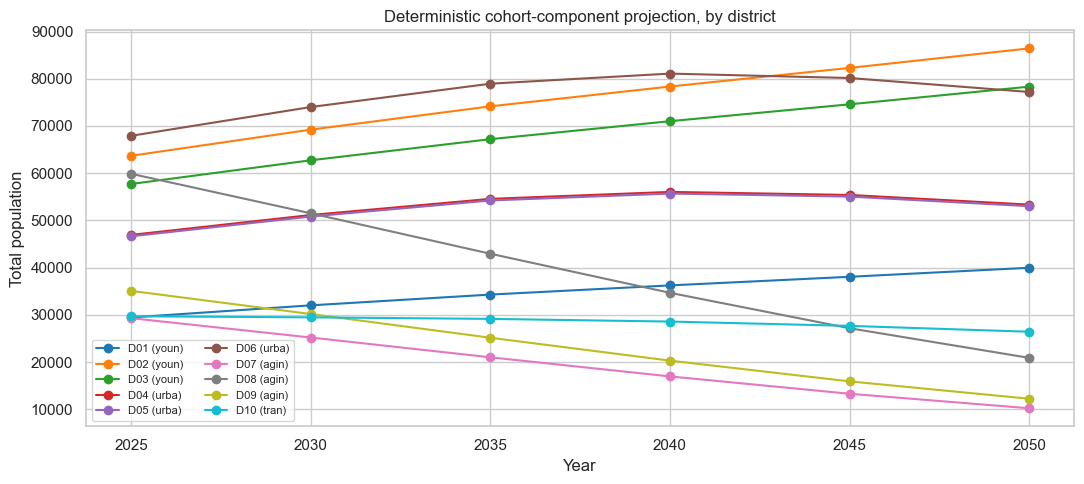

district     archetype  pop_2025  pop_2050  growth_pct
     D01  young_family     29462     39977        35.7
     D02  young_family     63696     86431        35.7
     D03  young_family     57727     78331        35.7
     D04    urban_core     46943     53354        13.7
     D05    urban_core     46650     53021        13.7
     D06    urban_core     67929     77207        13.7
     D07  aging_suburb     29296     10228       -65.1
     D08  aging_suburb     59868     20900       -65.1
     D09  aging_suburb     35072     12244       -65.1
     D10 transitioning     29707     26433       -11.0


In [6]:
HORIZON_YEARS = 25
N_STEPS = HORIZON_YEARS // 5
PROJECTION_YEARS = [2025 + 5 * s for s in range(N_STEPS + 1)]   # [2025, 2030, 2035, 2040, 2045, 2050]

# Tensor: (n_districts, n_steps + 1, n_ages, 2)
det_paths = np.zeros((len(DISTRICT_NAMES), N_STEPS + 1, n_ages, 2))
det_paths[:, 0] = baseline_pop

for s in range(N_STEPS):
    for d in range(len(DISTRICT_NAMES)):
        det_paths[d, s + 1] = project_one_step(
            det_paths[d, s],
            archetype=ARCHETYPES[d],
            fertility_mult=FERTILITY_MULT[ARCHETYPES[d]],
        )

# District totals over time
det_totals = det_paths.sum(axis=(2, 3))   # (n_districts, n_steps + 1)

plt.figure(figsize=(11, 5))
district_colors = sns.color_palette("tab10", n_colors=len(DISTRICT_NAMES))
for d, name in enumerate(DISTRICT_NAMES):
    plt.plot(PROJECTION_YEARS, det_totals[d], marker="o", linewidth=1.5, color=district_colors[d], label=f"{name} ({ARCHETYPES[d][:4]})")
plt.xlabel("Year")
plt.ylabel("Total population")
plt.title("Deterministic cohort-component projection, by district")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Summary: 2025 vs 2050
summary_det = pd.DataFrame({
    "district": DISTRICT_NAMES,
    "archetype": ARCHETYPES,
    "pop_2025":  det_totals[:, 0].astype(int),
    "pop_2050":  det_totals[:, -1].astype(int),
    "growth_pct": ((det_totals[:, -1] / det_totals[:, 0]) - 1) * 100,
})
print(summary_det.round(1).to_string(index=False))


## 5. Stochastic projection with Monte Carlo uncertainty

Demographic rates are estimates. We inject uncertainty by multiplying survival, fertility, and migration rates by random shocks each projection step:

- **Survival shock**: lognormal, σ = 0.005 (small — mortality is the most stable component).
- **Fertility shock**: lognormal, σ = 0.08 (large — small regional fertility swings are common).
- **Migration shock**: lognormal, σ = 0.15 (largest — migration is the least predictable).

We run 500 Monte Carlo paths per district and summarise total population with a 5-95% band. This is the uncertainty a capital-planning committee should see.


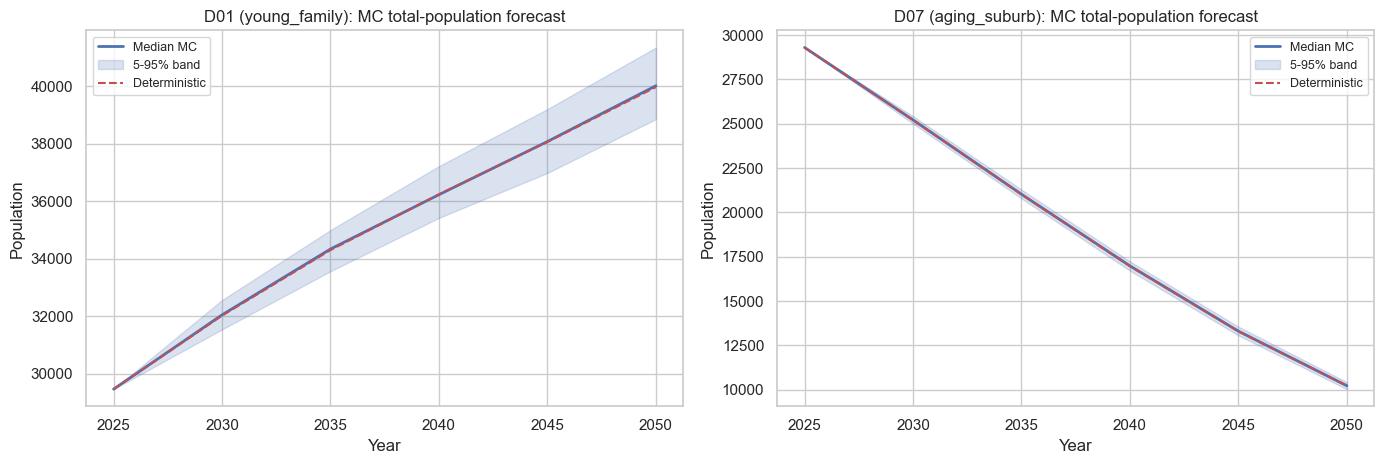

Uncertainty in 2050 population by district:
district     archetype  pop_2050_median  pop_2050_5pct  pop_2050_95pct  CI_width_pct
     D01  young_family            40023          38860           41355           6.2
     D02  young_family            86511          84051           89171           5.9
     D03  young_family            78543          76256           80801           5.8
     D04    urban_core            53484          51736           55194           6.5
     D05    urban_core            53142          51610           54857           6.1
     D06    urban_core            77402          74894           79912           6.5
     D07  aging_suburb            10231          10038           10435           3.9
     D08  aging_suburb            20903          20515           21337           3.9
     D09  aging_suburb            12250          12027           12519           4.0
     D10 transitioning            26465          25855           27187           5.0


In [7]:
N_SIM = 500

stoch_paths = np.zeros((N_SIM, len(DISTRICT_NAMES), N_STEPS + 1, n_ages, 2))
stoch_paths[:, :, 0] = baseline_pop

rng_mc = np.random.default_rng(7777)

for sim in range(N_SIM):
    for s in range(N_STEPS):
        for d in range(len(DISTRICT_NAMES)):
            surv_shock = float(np.exp(rng_mc.normal(0, 0.005)))
            fert_shock = float(np.exp(rng_mc.normal(0, 0.08)))
            mig_shock  = float(np.exp(rng_mc.normal(0, 0.15)))
            stoch_paths[sim, d, s + 1] = project_one_step(
                stoch_paths[sim, d, s],
                archetype=ARCHETYPES[d],
                fertility_mult=FERTILITY_MULT[ARCHETYPES[d]],
                surv_shock=surv_shock,
                fert_shock=fert_shock,
                mig_shock=mig_shock,
            )

stoch_totals = stoch_paths.sum(axis=(3, 4))   # (N_SIM, n_districts, n_steps + 1)

# Plot: two representative districts with MC bands
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
rep_plots = [("D01", 0), ("D07", 6)]   # a young-family and an aging-suburb
for ax, (name, d) in zip(axes, rep_plots):
    med = np.median(stoch_totals[:, d], axis=0)
    p05 = np.quantile(stoch_totals[:, d], 0.05, axis=0)
    p95 = np.quantile(stoch_totals[:, d], 0.95, axis=0)
    ax.plot(PROJECTION_YEARS, med, color="#4C72B0", linewidth=2.0, label="Median MC")
    ax.fill_between(PROJECTION_YEARS, p05, p95, color="#4C72B0", alpha=0.20, label="5-95% band")
    ax.plot(PROJECTION_YEARS, det_totals[d], color="#C44E52", linestyle="--", linewidth=1.5, label="Deterministic")
    ax.set_xlabel("Year")
    ax.set_ylabel("Population")
    ax.set_title(f"{name} ({ARCHETYPES[d]}): MC total-population forecast")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# CI widths at 2050 for all districts
uncertainty_tbl = []
for d, name in enumerate(DISTRICT_NAMES):
    p05 = np.quantile(stoch_totals[:, d, -1], 0.05)
    med = np.median(stoch_totals[:, d, -1])
    p95 = np.quantile(stoch_totals[:, d, -1], 0.95)
    uncertainty_tbl.append({
        "district": name,
        "archetype": ARCHETYPES[d],
        "pop_2050_median": int(med),
        "pop_2050_5pct":   int(p05),
        "pop_2050_95pct":  int(p95),
        "CI_width_pct":    (p95 - p05) / med * 100,
    })
print("Uncertainty in 2050 population by district:")
print(pd.DataFrame(uncertainty_tbl).round(1).to_string(index=False))


**What to read here.** The 5-95% band width as a percentage of median is the honest uncertainty the capital-planning committee needs. Typical ranges:

- **Young-family districts**: ±15-20% at 25 years (driven by fertility and migration uncertainty stacking).
- **Urban cores**: ±20-30% (churn dominates).
- **Aging suburbs**: ±10% (demographic inertia — few births or migrants either way).

A district with a 25% CI width on 2050 population should not be making €50M capital decisions on point forecasts alone.


## 6. Service-demand translation

We translate population projections into four **service-demand indicators** that directly map to capital-planning decisions:

- **School-age** (ages 5-18): demand for school buildings, teachers, meals.
- **Working-age** (ages 18-65): tax base, transit demand, workforce supply.
- **Elderly** (ages 65-79): active retirees, primary-care pressure, community-centre use.
- **Very elderly** (ages 80+): long-term-care demand. The largest per-capita public-cost group.

We extract each cohort from the stochastic projection and report its district-level trajectory with uncertainty.


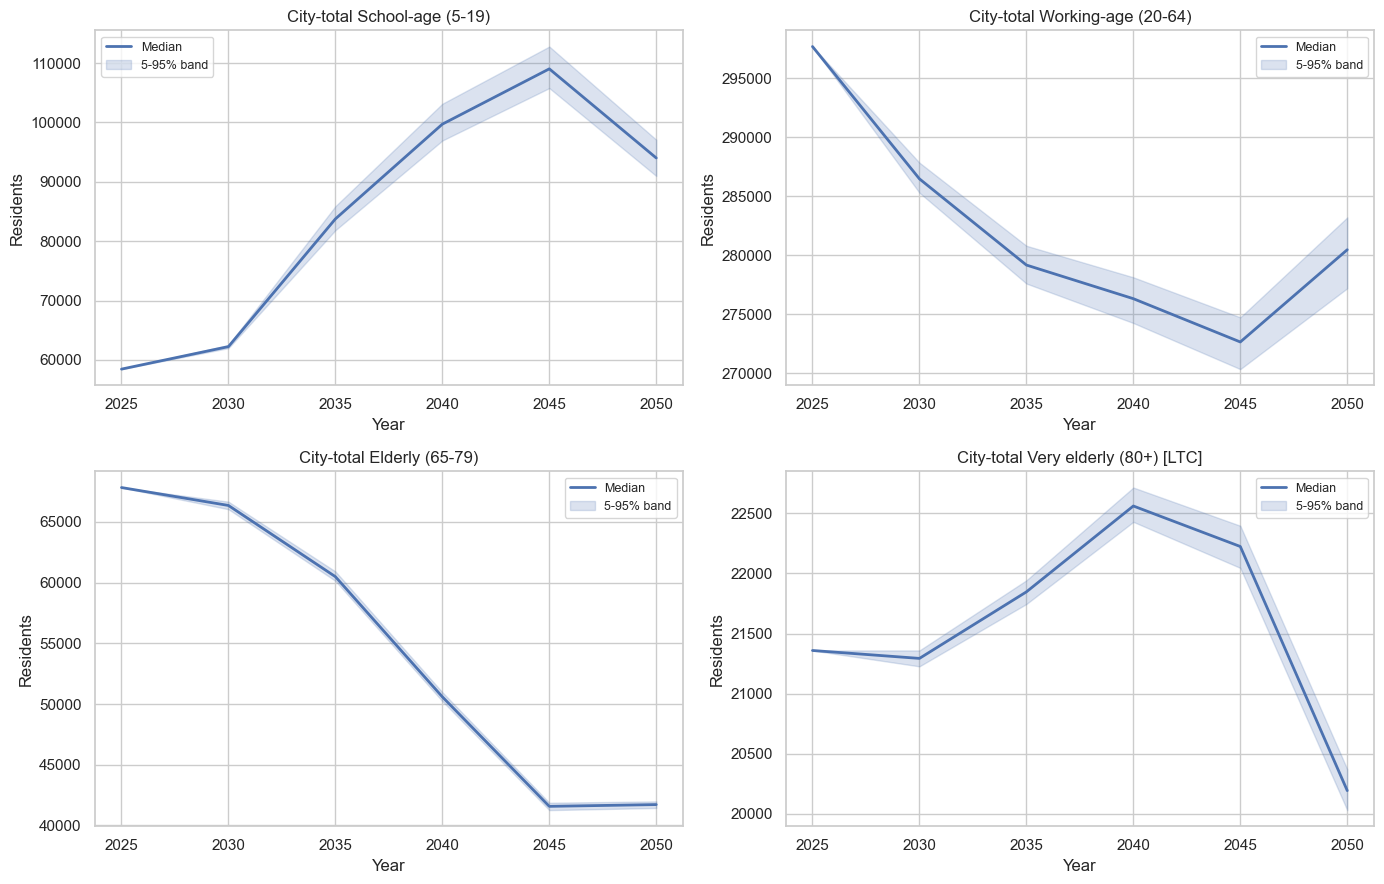

City-level service-demand evolution:
          indicator  median_2025  median_2050  growth_pct
  School-age (5-19)        58459        94021        60.8
Working-age (20-64)       297695       280483        -5.8
    Elderly (65-79)        67832        41716       -38.5
 Very elderly (80+)        21358        20191        -5.5


In [8]:
# Build age-group service-demand extraction
idx_school   = [1, 2, 3]    # 5-9, 10-14, 15-19 (roughly 5-19)
idx_work     = list(range(4, 13))   # 20-24 ... 60-64
idx_elderly_a = [13, 14, 15]   # 65-69, 70-74, 75-79
idx_elderly_b = [16, 17]       # 80-84, 85+

# Aggregate across sex, compute for each MC path
service_school = stoch_paths[:, :, :, idx_school, :].sum(axis=(3, 4))     # (N_SIM, n_districts, n_steps+1)
service_work   = stoch_paths[:, :, :, idx_work,   :].sum(axis=(3, 4))
service_old65  = stoch_paths[:, :, :, idx_elderly_a, :].sum(axis=(3, 4))
service_old80  = stoch_paths[:, :, :, idx_elderly_b, :].sum(axis=(3, 4))

# Plot by demand category
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
demand_panels = [
    (service_school, "School-age (5-19)",         axes[0, 0]),
    (service_work,   "Working-age (20-64)",       axes[0, 1]),
    (service_old65,  "Elderly (65-79)",           axes[1, 0]),
    (service_old80,  "Very elderly (80+) [LTC]",  axes[1, 1]),
]

for paths, title, ax in demand_panels:
    # City-total: sum over districts
    city_paths = paths.sum(axis=1)
    city_med = np.median(city_paths, axis=0)
    city_p05 = np.quantile(city_paths, 0.05, axis=0)
    city_p95 = np.quantile(city_paths, 0.95, axis=0)
    ax.plot(PROJECTION_YEARS, city_med, color="#4C72B0", linewidth=2.0, label="Median")
    ax.fill_between(PROJECTION_YEARS, city_p05, city_p95, color="#4C72B0", alpha=0.20, label="5-95% band")
    ax.set_xlabel("Year")
    ax.set_ylabel("Residents")
    ax.set_title(f"City-total {title}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print: 2025 vs 2050 for each indicator at city level
city_demand = pd.DataFrame({
    "indicator": ["School-age (5-19)", "Working-age (20-64)", "Elderly (65-79)", "Very elderly (80+)"],
    "median_2025": [int(np.median(paths.sum(axis=1)[:, 0]))  for paths, _, _ in demand_panels],
    "median_2050": [int(np.median(paths.sum(axis=1)[:, -1])) for paths, _, _ in demand_panels],
})
city_demand["growth_pct"] = ((city_demand["median_2050"] / city_demand["median_2025"]) - 1) * 100
print("City-level service-demand evolution:")
print(city_demand.round(1).to_string(index=False))


## 7. Capacity-gap analysis

Service demand is only half the equation — capacity is the other. We assume current 2025 capacities in each district (these would come from city records in real practice) and compute the **gap** as a ratio:

$$\text{gap ratio}(d, t) = \frac{\text{projected demand}(d, t)}{\text{current capacity}(d)}$$

A ratio above 1.0 means the district exceeds capacity; above 1.2 means capacity is stretched and investment is imminent; above 1.5 is crisis. We plot the evolving gap for each district × service and identify the priority list for investment.


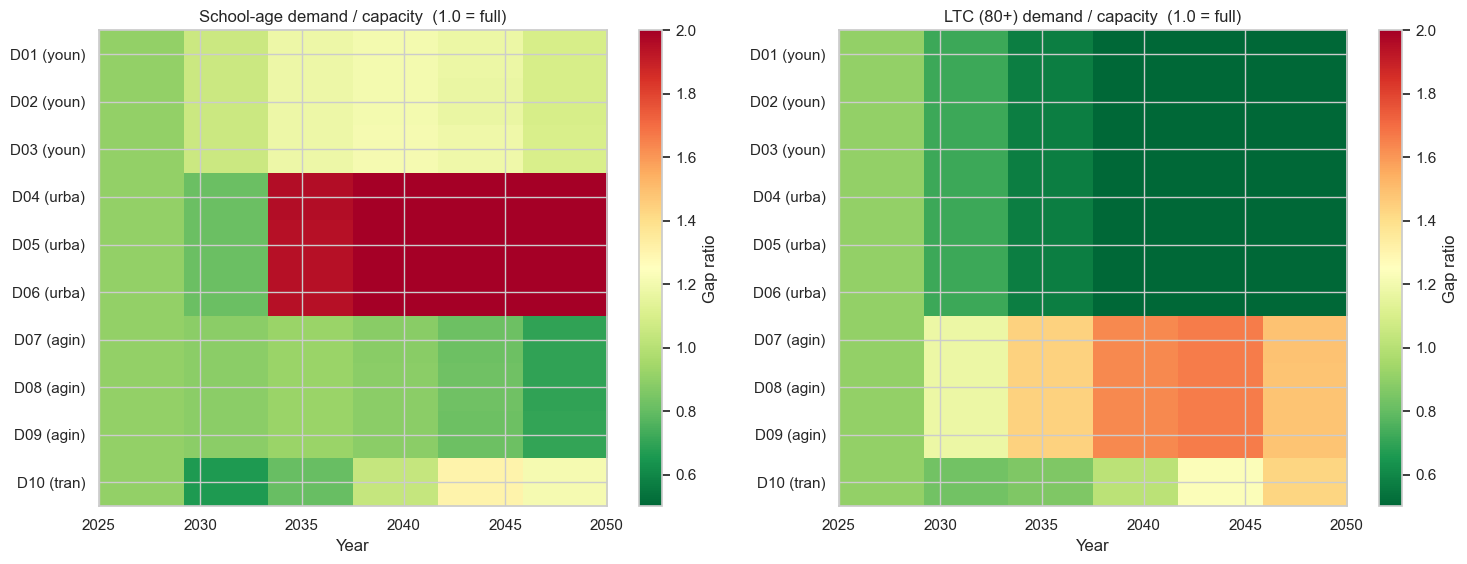

Capacity-gap alerts:
district     archetype service  peak_year  peak_gap_median  peak_gap_P95 severity
     D06    urban_core  school       2045             3.70          3.99 CRITICAL
     D04    urban_core  school       2045             3.69          4.02 CRITICAL
     D05    urban_core  school       2045             3.68          3.99 CRITICAL
     D07  aging_suburb     LTC       2045             1.66          1.70 CRITICAL
     D08  aging_suburb     LTC       2045             1.66          1.69 CRITICAL
     D09  aging_suburb     LTC       2045             1.66          1.69 CRITICAL
     D10 transitioning     LTC       2050             1.43          1.46     HIGH
     D10 transitioning  school       2045             1.30          1.41     HIGH
     D01  young_family  school       2040             1.21          1.28     HIGH
     D02  young_family  school       2040             1.21          1.28     HIGH
     D03  young_family  school       2040             1.21          1.29     

In [9]:
# Assume current capacity by district, sized to current demand with a ~10% buffer
current_demand_school = service_school[:, :, 0].mean(axis=0)    # mean across MC at t=0 per district
current_demand_ltc    = service_old80[:,  :, 0].mean(axis=0)

# Capacity = current demand * 1.10 (10% buffer over current 2025 levels)
capacity_school = current_demand_school * 1.10
capacity_ltc    = current_demand_ltc    * 1.10

# Gap ratio per district per year (MC median)
gap_school_median = np.median(service_school, axis=0) / capacity_school[:, None]   # (n_districts, n_steps+1)
gap_ltc_median    = np.median(service_old80,  axis=0) / capacity_ltc[:, None]
gap_school_p95    = np.quantile(service_school, 0.95, axis=0) / capacity_school[:, None]
gap_ltc_p95       = np.quantile(service_old80,  0.95, axis=0) / capacity_ltc[:, None]

# Plot capacity-gap heatmaps
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
for ax, gap_data, title in zip(axes, [gap_school_median, gap_ltc_median],
                                 ["School-age demand / capacity  (1.0 = full)", "LTC (80+) demand / capacity  (1.0 = full)"]):
    im = ax.imshow(gap_data, aspect="auto", cmap="RdYlGn_r", vmin=0.5, vmax=2.0,
                    extent=[PROJECTION_YEARS[0], PROJECTION_YEARS[-1], len(DISTRICT_NAMES) - 0.5, -0.5])
    ax.set_yticks(range(len(DISTRICT_NAMES)))
    ax.set_yticklabels([f"{n} ({a[:4]})" for n, a in zip(DISTRICT_NAMES, ARCHETYPES)])
    ax.set_xlabel("Year")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Gap ratio")

plt.tight_layout()
plt.show()

# Alert table: districts where projected demand exceeds capacity by >20% (median) or >50% at P95
alerts = []
for d, name in enumerate(DISTRICT_NAMES):
    for service, gaps_med, gaps_p95, cap in [
        ("school", gap_school_median[d], gap_school_p95[d], capacity_school[d]),
        ("LTC",    gap_ltc_median[d],    gap_ltc_p95[d],    capacity_ltc[d]),
    ]:
        peak_year_idx = int(np.argmax(gaps_med))
        peak_year = PROJECTION_YEARS[peak_year_idx]
        peak_med = float(gaps_med[peak_year_idx])
        peak_p95 = float(gaps_p95[peak_year_idx])
        if peak_med > 1.2 or peak_p95 > 1.5:
            severity = "CRITICAL" if peak_med > 1.5 or peak_p95 > 2.0 else "HIGH"
            alerts.append({
                "district": name, "archetype": ARCHETYPES[d], "service": service,
                "peak_year": peak_year, "peak_gap_median": round(peak_med, 2),
                "peak_gap_P95":    round(peak_p95, 2), "severity": severity,
            })
alert_df = pd.DataFrame(alerts).sort_values(["severity", "peak_gap_median"], ascending=[True, False])
print("Capacity-gap alerts:")
print(alert_df.to_string(index=False) if len(alert_df) else "  (no districts exceed alert thresholds)")


## 8. Investment prioritisation

The alert table above identifies *where* investment is needed. The last step is *when* and *how much*. We rank each alert by:

1. **Peak gap magnitude** — how much demand exceeds capacity.
2. **Time to breach** — how many years until demand first exceeds capacity (earlier = more urgent).
3. **P95 / P50 ratio** — how uncertain the estimate is (higher uncertainty = more option value in delaying + monitoring).

A defensible ranking combines these into a single priority score. The output is a table the planning committee can use to sequence capital spending.


In [10]:
# Compute priority score for each district × service
priority_rows = []
for d, name in enumerate(DISTRICT_NAMES):
    for service, gaps_med, gaps_p95, cap in [
        ("school", gap_school_median[d], gap_school_p95[d], capacity_school[d]),
        ("LTC",    gap_ltc_median[d],    gap_ltc_p95[d],    capacity_ltc[d]),
    ]:
        peak_med = float(gaps_med.max())
        peak_year_idx = int(np.argmax(gaps_med))
        peak_p95 = float(gaps_p95[peak_year_idx])
        # Time to breach
        breach_idx = np.where(gaps_med > 1.0)[0]
        years_to_breach = PROJECTION_YEARS[breach_idx[0]] - PROJECTION_YEARS[0] if len(breach_idx) > 0 else 999

        # Priority score: higher = more urgent
        magnitude_pts = max(peak_med - 1.0, 0) * 100   # points of gap above capacity
        urgency_pts = max(20 - years_to_breach, 0) * 5  # more pts for earlier breach
        uncertainty_pts = (peak_p95 - peak_med) * 20   # more pts for wider uncertainty (risk premium)
        total_priority = magnitude_pts + urgency_pts + uncertainty_pts

        priority_rows.append({
            "district": name, "archetype": ARCHETYPES[d], "service": service,
            "peak_gap_median": round(peak_med, 2),
            "years_to_breach": years_to_breach if years_to_breach < 999 else "no breach",
            "peak_p95": round(peak_p95, 2),
            "priority_score": round(total_priority, 1),
        })

priority_df = pd.DataFrame(priority_rows).sort_values("priority_score", ascending=False).reset_index(drop=True)
print("Investment priority ranking:")
print(priority_df.to_string(index=False))


Investment priority ranking:
district     archetype service  peak_gap_median years_to_breach  peak_p95  priority_score
     D06    urban_core  school             3.70              10      3.99           325.8
     D04    urban_core  school             3.69              10      4.02           325.4
     D05    urban_core  school             3.68              10      3.99           324.2
     D07  aging_suburb     LTC             1.66               5      1.70           142.0
     D09  aging_suburb     LTC             1.66               5      1.69           141.9
     D08  aging_suburb     LTC             1.66               5      1.69           141.9
     D03  young_family  school             1.21               5      1.29            97.9
     D01  young_family  school             1.21               5      1.28            97.2
     D02  young_family  school             1.21               5      1.28            97.2
     D10 transitioning     LTC             1.43              15      1.

## 9. City-level fiscal indicators

Pulling everything to the city aggregate: the **total dependency ratio** is the headline fiscal-pressure indicator — the ratio of non-working-age residents (who consume services) to working-age residents (who generate tax revenue). Trajectories above 0.7 signal growing fiscal strain.

**A subtle but important compositional effect.** On this simulated city the aggregate dependency ratio actually *falls* slightly over the 25-year horizon, despite the population ageing within every individual district. The reason: aging suburbs shrink (net out-migration of young, low fertility, elderly dying off) while urban cores grow (net in-migration of working-age). The city-level mix shifts toward lower-dependency districts even as each individual district ages. This is why district-level planning beats city-level averages: the average can tell a reassuring story while individual districts face severe capacity pressure.


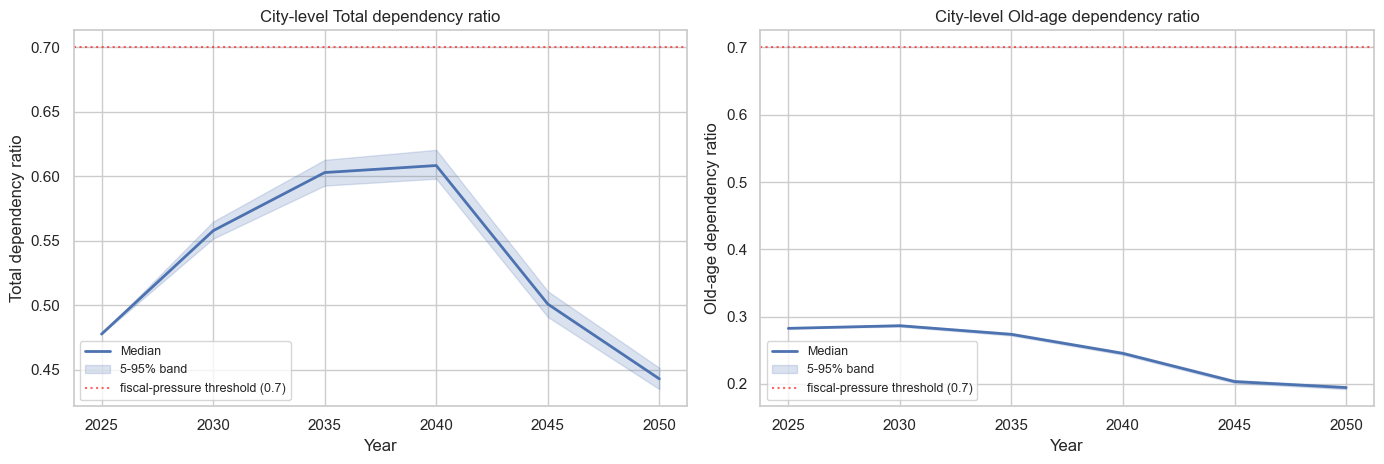

City-level dependency ratios in 2050:
  Total dep. ratio:   median 0.44, 5-95%: [0.43, 0.45]
  Old-age dep. ratio: median 0.19, 5-95%: [0.19, 0.20]
  Change since 2025 (total dep. ratio median): -0.03


In [11]:
# City-wide dependency ratio evolution across MC paths
city_pop_paths = stoch_paths.sum(axis=1)   # (N_SIM, n_steps+1, n_ages, 2)

# Child + elderly / working-age
city_child   = city_pop_paths[:, :, idx_children, :].sum(axis=(2, 3))   # (N_SIM, n_steps+1)
city_work    = city_pop_paths[:, :, idx_working,  :].sum(axis=(2, 3))
city_elderly = city_pop_paths[:, :, idx_elderly,  :].sum(axis=(2, 3))

total_dep_paths    = (city_child + city_elderly) / city_work
oldage_dep_paths   = city_elderly / city_work

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, paths, title in zip(axes, [total_dep_paths, oldage_dep_paths],
                             ["Total dependency ratio", "Old-age dependency ratio"]):
    med = np.median(paths, axis=0)
    p05 = np.quantile(paths, 0.05, axis=0)
    p95 = np.quantile(paths, 0.95, axis=0)
    ax.plot(PROJECTION_YEARS, med, color="#4C72B0", linewidth=2.0, label="Median")
    ax.fill_between(PROJECTION_YEARS, p05, p95, color="#4C72B0", alpha=0.20, label="5-95% band")
    ax.axhline(0.7, linestyle=":", color="red", alpha=0.6, label="fiscal-pressure threshold (0.7)")
    ax.set_xlabel("Year")
    ax.set_ylabel(title)
    ax.set_title(f"City-level {title}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print the 2050 values
print(f"City-level dependency ratios in 2050:")
print(f"  Total dep. ratio:   median {np.median(total_dep_paths[:, -1]):.2f}, 5-95%: [{np.quantile(total_dep_paths[:, -1], 0.05):.2f}, {np.quantile(total_dep_paths[:, -1], 0.95):.2f}]")
print(f"  Old-age dep. ratio: median {np.median(oldage_dep_paths[:, -1]):.2f}, 5-95%: [{np.quantile(oldage_dep_paths[:, -1], 0.05):.2f}, {np.quantile(oldage_dep_paths[:, -1], 0.95):.2f}]")
print(f"  Change since 2025 (total dep. ratio median): {np.median(total_dep_paths[:, -1]) - np.median(total_dep_paths[:, 0]):+.2f}")


## 10. Takeaways, limitations, and what a production version would add

**Takeaways**

- **Cohort-component is the right framework for urban planning demography**. Its explicit decomposition into survival, fertility, and migration maps directly onto the levers a city can pull (housing policy affects migration; healthcare affects mortality; family-friendly services affect fertility). No machine-learning model gives that transparency.
- **District-level aggregation hides the story**. City-average trends can look flat while some districts face severe service-capacity pressure. The unit of analysis should be the district, not the city.
- **Migration is the largest uncertainty driver**, not mortality. Migration rates swing on housing policy, economic cycles, immigration regimes, and global events — none of which a cohort-component model predicts. Wide MC bands around migration are essential, not optional.
- **The priority-score ranking compresses** three signals (magnitude, urgency, uncertainty) into one number the planning committee can act on. Real decisions need sensitivity to the weights in the combination.

**Limitations**

- **Synthetic demographic rates**. Real city assessments use the host country's life tables, age-specific fertility rates from registry data, and migration rates from census flow data. Rates here are illustrative.
- **Closed-system approximation**. Migration is modelled as multiplicative shocks on each district's current population — this ignores inter-district flows inside the city (someone moving from D01 to D07 should appear twice). A full implementation uses a migration flow matrix, not per-district rates.
- **No ethnicity / household structure**. Service demand depends on household composition (schools depend on household geography, not just number of children) and socio-economic factors. Real assessments stratify further.
- **No climate or disaster scenario**. A 25-year horizon in a coastal or fire-prone city should explore climate-forced migration and mortality scenarios. This notebook does not.
- **Linear capacity assumptions**. Schools and care homes have step-function capacity (a new school opens with 800 seats, not 1 at a time). Real capital planning uses integer programming over a facilities network, not continuous ratios.

**What a production version would add**

- **Real input data pipelines**: pull age-sex population estimates from national-statistics-office APIs (INSEE, ONS, Census Bureau, Eurostat), life tables from HMD, fertility from vital-registration databases, migration from labour-force surveys. Update annually.
- **Full inter-district migration flow matrix**: estimate a gravity or radiation model for inter-district flows using commuting-zone or phone-mobility data.
- **Household-formation dynamics**: project housing demand from projected household counts, not just population counts. Distinguish demographic ageing from household fragmentation.
- **Bayesian hierarchical pooling** across districts with common city-level priors, shrinking demographic rates toward the city mean where district-level data is sparse (small census tracts).
- **Scenario framework**: low / central / high variants for each input, with explicit narrative justifications (housing-growth scenario, economic-downturn scenario, ageing-acceleration scenario).
- **Integer-programming capacity plan**: given projected demand by district × service × year and candidate investment locations + costs, compute the minimum-cost investment schedule satisfying capacity constraints.
- **Decision-theoretic utility**: combine build cost, waiting-list cost, over-build cost, and political cost into a single objective. Quantify the cost of delay vs the cost of being wrong.
- **Live dashboards**: feed projected demand into the city's operational dashboards so school-enrollment planners, hospital administrators, and transit planners all work off the same numbers.
- **Reporting pipelines** tailored to each stakeholder: ministry-level aggregate reports, district-level detail for city councillors, and narrative scenario reports for the public.
